# Wikimedia Project

Indoor vs outdoor image classification project report.

## 1. Data Sources
- WIT dataset (wikimedia/wit_base)
- Candidate pool created with CLIP filtering

In [1]:
# Imports
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from torchvision import models, transforms

sns.set_theme(style='whitegrid')

In [2]:
# Paths
ROOT = Path('..')
POOL_DIR = ROOT / 'pool'
TRAIN_DIR = ROOT / 'train_set'

POOL_LABELS = POOL_DIR / 'labels.csv'
TRAIN_LABELS = TRAIN_DIR / 'labels.csv'

In [3]:
# Load labels if they exist
pool_df = pd.read_csv(POOL_LABELS) if POOL_LABELS.exists() else None
train_df = pd.read_csv(TRAIN_LABELS) if TRAIN_LABELS.exists() else None

pool_df.head() if pool_df is not None else 'Pool labels not found'

,image_id,url,width,height,photo_prob,inside_prob,outside_prob,weak_label
0,img_0000000,NaN,300,431,0.8709,0.8817,0.1183,inside
1,img_0000001,NaN,300,400,0.9730,0.0067,0.9933,outside
2,img_0000002,NaN,300,437,0.9536,0.6584,0.3416,inside
3,img_0000003,NaN,300,400,0.9371,0.9960,0.0040,inside
4,img_0000004,NaN,300,400,0.8995,0.0898,0.9102,outside


In [4]:
# Candidate pool stats
if pool_df is not None:
    display(pool_df['weak_label'].value_counts())
    display(pool_df[['photo_prob', 'inside_prob', 'outside_prob']].describe())

weak_label
inside     10000
outside    10000
Name: count, dtype: int64

,photo_prob,inside_prob,outside_prob
count,20000.000000,20000.000000,20000.000000
mean,0.911247,0.482927,0.517073
std,0.074294,0.351941,0.351941
min,0.700000,0.000600,0.000100
25%,0.872775,0.128275,0.190400
50%,0.936500,0.500050,0.499950
75%,0.969100,0.809600,0.871725
max,0.999200,0.999900,0.999400


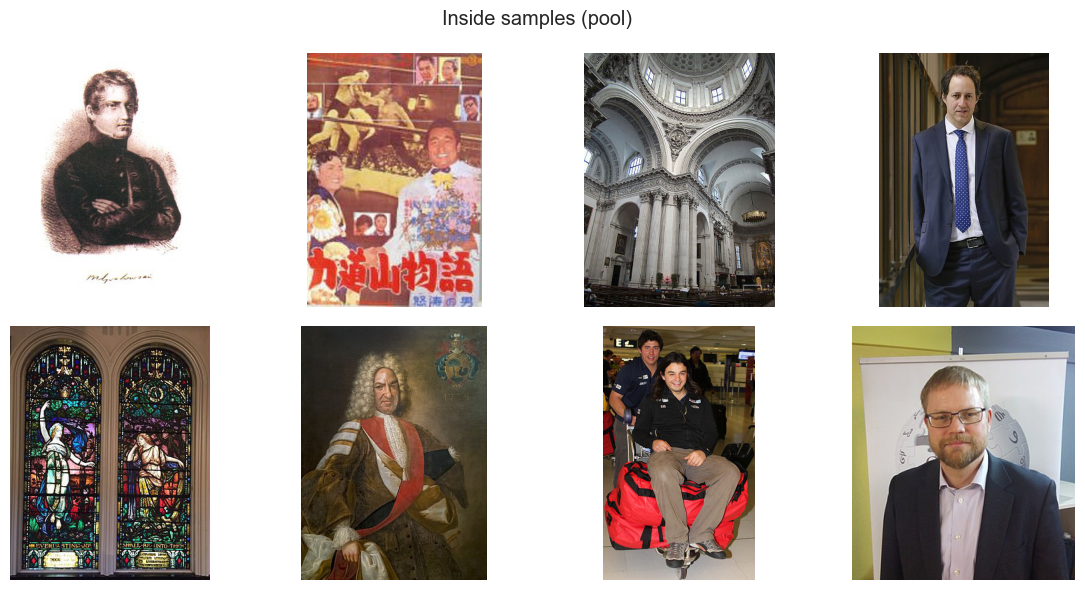

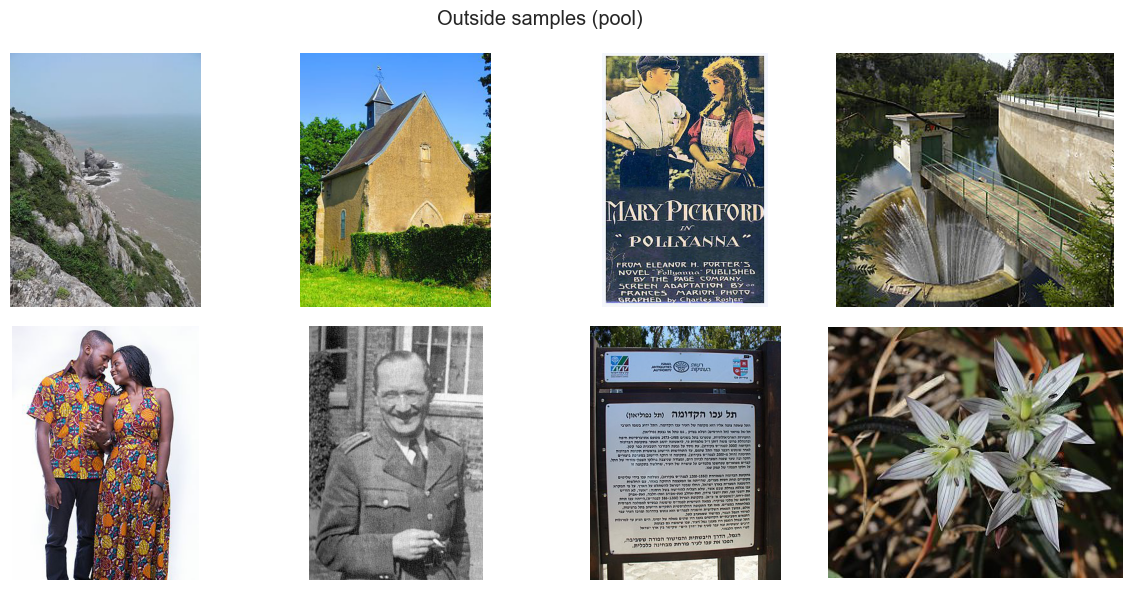

In [5]:
# Show a grid of sample images
def show_grid(image_paths, rows=2, cols=4, title=None):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()
    for ax, path in zip(axes, image_paths):
        img = Image.open(path)
        ax.imshow(img)
        ax.axis('off')
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    plt.show()

inside_paths = list((POOL_DIR / 'inside').glob('*.jpg'))[:8]
outside_paths = list((POOL_DIR / 'outside').glob('*.jpg'))[:8]
if inside_paths:
    show_grid(inside_paths, title='Inside samples (pool)')
if outside_paths:
    show_grid(outside_paths, title='Outside samples (pool)')

## 2. Gold test evaluation

Evaluate both models on the gold test split and visualize correct vs incorrect predictions.

In [6]:
# Gold test setup
ROOT = Path('..')
CHECKPOINTS = {
    'finetune': ROOT / 'checkpoints' / 'full_fine_tune' / 'best.pt',
    'baseline_logistic': ROOT / 'checkpoints' / 'baseline_logistic' / 'best.pt',
}
GOLD_TEST_CSV = ROOT / 'pool' / 'splits' / 'test.csv'

def load_checkpoint_model(ckpt_path: Path) -> tuple[torch.nn.Module, list[str]]:
    checkpoint = torch.load(ckpt_path, map_location='cpu')
    classes = checkpoint['classes']
    model = models.resnet50(weights=None)
    model.fc = torch.nn.Linear(model.fc.in_features, len(classes))
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model, classes

def build_val_transform():
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

class GoldTestDataset(torch.utils.data.Dataset):
    def __init__(self, csv_path: Path, class_to_idx: dict[str, int], transform, root: Path):
        self.items = []
        self.transform = transform
        self.root = root
        if not csv_path.exists():
            return
        df = pd.read_csv(csv_path)
        for _, row in df.iterrows():
            label = row['label']
            raw_path = str(row['path']).replace('\\', '/')
            path = Path(raw_path)
            if not path.is_absolute():
                path = self.root / path
            if label not in class_to_idx or not path.exists():
                continue
            self.items.append((path, class_to_idx[label]))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        image = Image.open(path).convert('RGB')
        return self.transform(image), label, str(path)

In [7]:
# Evaluate models on gold test
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
val_tf = build_val_transform()
results = {}

for name, ckpt_path in CHECKPOINTS.items():
    if not ckpt_path.exists():
        print(f'Missing checkpoint: {ckpt_path}')
        continue
    model, classes = load_checkpoint_model(ckpt_path)
    model.to(device)
    class_to_idx = {label: idx for idx, label in enumerate(classes)}
    dataset = GoldTestDataset(GOLD_TEST_CSV, class_to_idx, val_tf, ROOT)
    loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False)
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_paths = []
    with torch.no_grad():
        for images, labels, paths in loader:
            images = images.to(device)
            logits = model(images)
            preds = torch.argmax(logits, dim=1).cpu().tolist()
            labels = labels.tolist()
            all_preds.extend(preds)
            all_labels.extend(labels)
            all_paths.extend(paths)
            correct += sum(p == y for p, y in zip(preds, labels))
            total += len(labels)
    acc = correct / max(total, 1)
    results[name] = {
        'accuracy': acc,
        'classes': classes,
        'preds': all_preds,
        'labels': all_labels,
        'paths': all_paths,
    }
    print(f'{name}: accuracy={acc:.4f} on {total} images')

finetune: accuracy=0.8300 on 300 images
baseline_logistic: accuracy=0.8500 on 300 images


finetune correct examples:


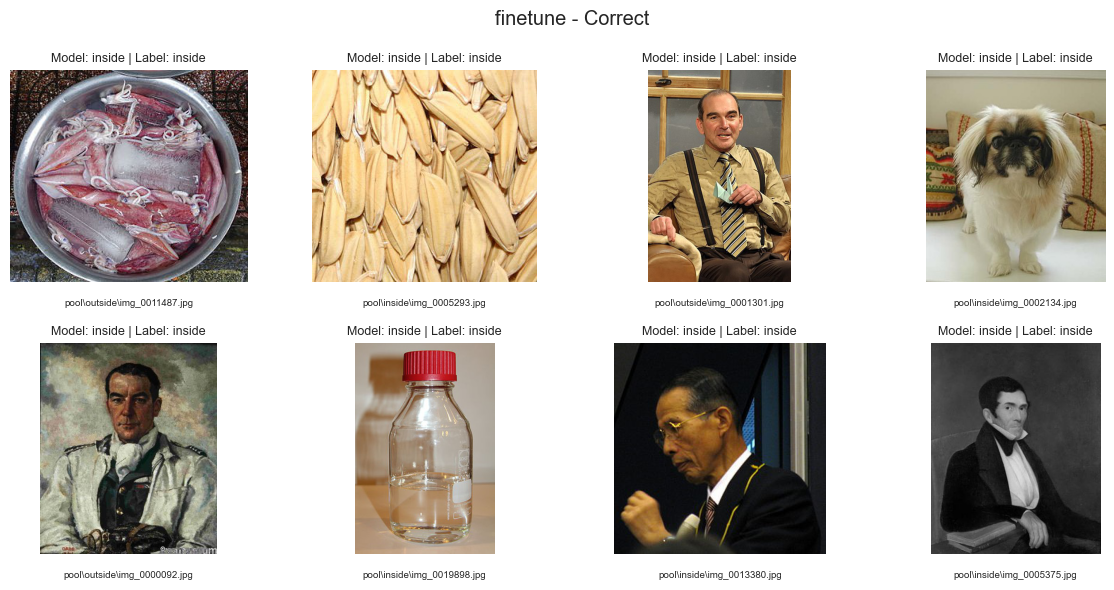

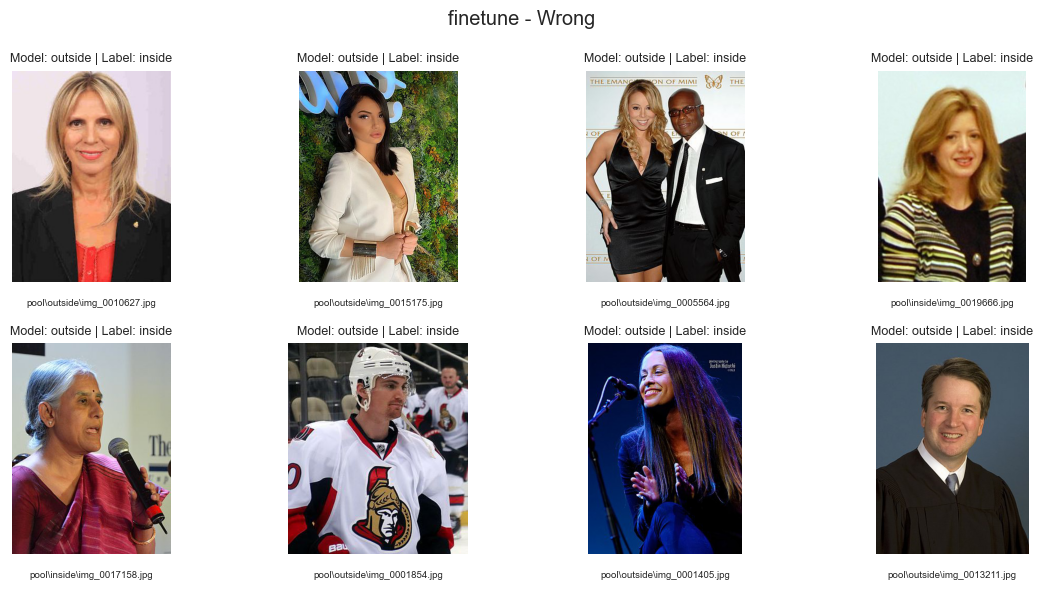

baseline_logistic correct examples:


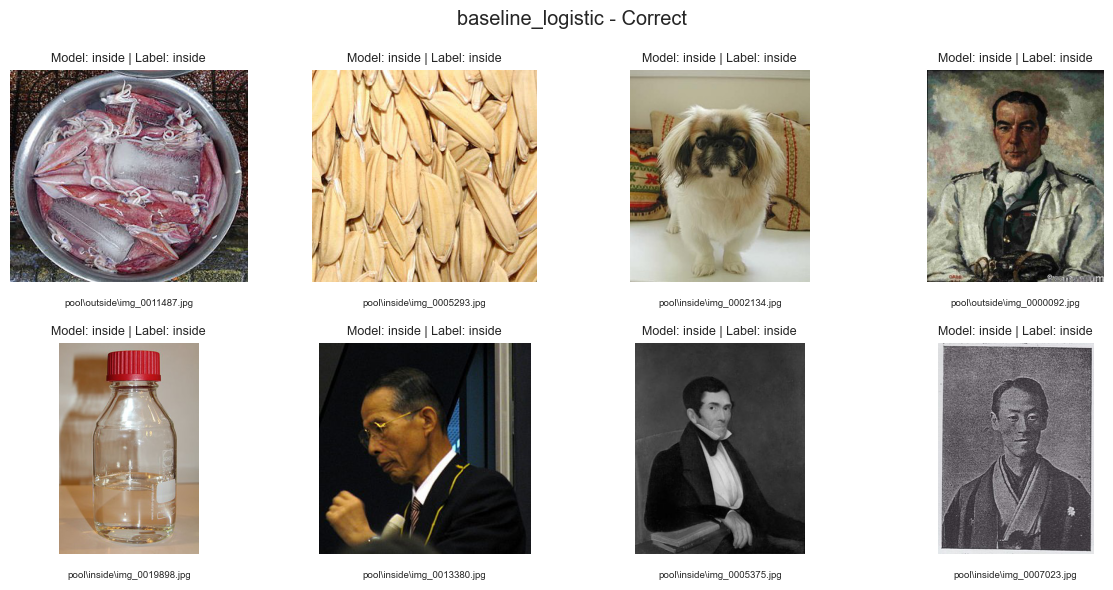

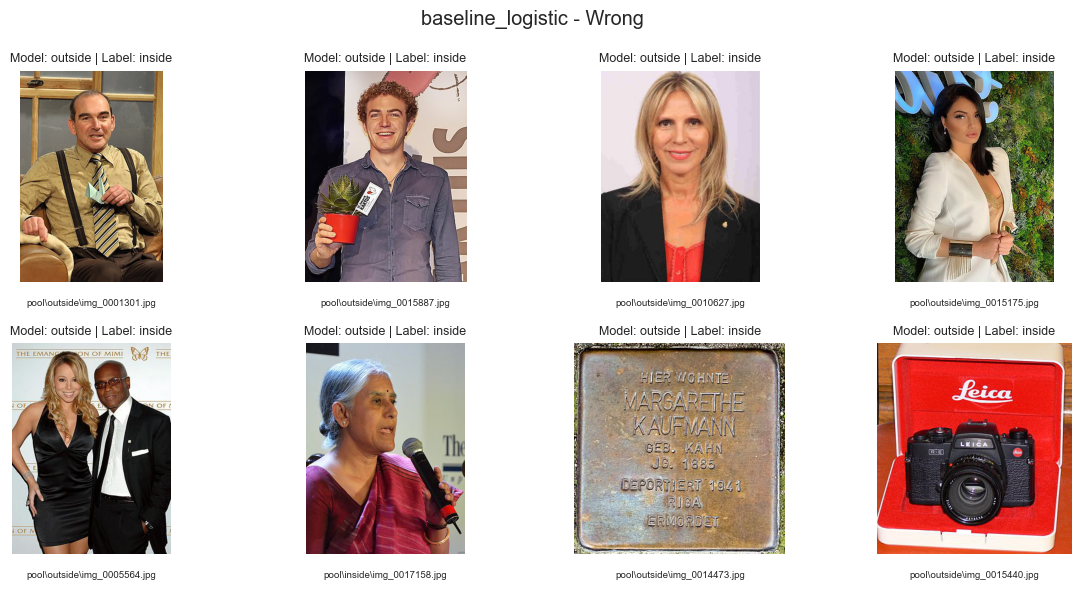

In [8]:
# Visualize correct and incorrect predictions
def show_examples(name, results_dict, limit=8):
    if name not in results_dict:
        return
    classes = results_dict[name]['classes']
    preds = results_dict[name]['preds']
    labels = results_dict[name]['labels']
    paths = results_dict[name]['paths']

    correct_items = [(p, y, path) for p, y, path in zip(preds, labels, paths) if p == y]
    wrong_items = [(p, y, path) for p, y, path in zip(preds, labels, paths) if p != y]

    print(f'{name} correct examples:')
    for title, items in [("Correct", correct_items), ("Wrong", wrong_items)]:
        if not items:
            print(f'No {title.lower()} examples to show.')
            continue
        sample = items[:limit]
        cols = 4
        rows = max(1, (len(sample) + cols - 1) // cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
        for ax, (pred, label, path) in zip(axes, sample):
            img = Image.open(path).convert('RGB')
            ax.imshow(img)
            ax.axis('off')
            title_text = f"Model: {classes[pred]} | Label: {classes[label]}"
            ax.set_title(title_text, fontsize=9)
            try:
                rel_path = Path(path).resolve().relative_to(ROOT.resolve())
                path_text = str(rel_path)
            except Exception:
                path_text = Path(path).name
            ax.text(0.5, -0.08, path_text, transform=ax.transAxes, ha='center', va='top', fontsize=7)
        for ax in axes[len(sample):]:
            ax.axis('off')
        fig.suptitle(f'{name} - {title}')
        fig.tight_layout()
        plt.show()

for model_name in results.keys():
    show_examples(model_name, results, limit=8)